In [1]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from sklearn.metrics import confusion_matrix

### Hyperparameters

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 64
max_epoch = 10
train_iters = 5000
alpha = 0.0001
decay = 0.00001
eval_iters = 1000
dropout = 0.5
np.random.seed(0)
torch.manual_seed(0)

### Training Data Reading and Map generation

In [3]:
# Load training data Set
with open("OCR Neural Network/Datasets/emnist-balanced-train.csv", "r") as f:
    reader = csv.reader(f)
    data_clump = np.array(list(reader), dtype=np.uint8)

In [4]:
maps = open("OCR Neural Network/Datasets/emnist-balanced-mapping.txt",'r')
maps = {i:chr(int(j)) for i,j in [line.split() for line in maps.readlines()]}

### Test Data Reading

In [5]:
with open("OCR Neural Network/Datasets/emnist-balanced-test.csv", "r") as f:
    reader = csv.reader(f)
    test_data_clump = np.array(list(reader), dtype=np.uint8)

### Data pre processing

In [6]:
#creating the training set
head_train = data_clump[:,0] 
img_px_train = data_clump[:,1:]

#normalizing the data
trainmean = np.mean(img_px_train)
trainstd = np.std(img_px_train)
img_px_train = (img_px_train - trainmean) / trainstd
img_px_train = img_px_train.reshape(-1, 28, 28)

#creating the test set
head_test = test_data_clump[:,0] 
img_px_test = test_data_clump[:,1:]

#normalizing the data
img_px_test = (img_px_test - trainmean) / trainstd
img_px_test = img_px_test.reshape(-1, 28, 28)


'''
No need to reshape and use pillow to convert to image.
EMNIST dataset already has rotations embedded in it.
'''
frame_train = pd.DataFrame({'Label' : head_train,  'Image' : img_px_train.tolist()})
frame_test = pd.DataFrame({'Label' : head_test,  'Image' : img_px_test.tolist()})

In [7]:
def get_batch(split):
    data = frame_train if split == 'train' else frame_test
    data = data.sample(batch_size)
    X = torch.tensor(data['Image'].values.tolist(), dtype=torch.float32).view(-1, 1, 28, 28)
    y = torch.tensor(data['Label'].values.tolist(), dtype=torch.long)
    X,y = X.to(device), y.to(device)
    return X, y

### Designing the CNN Layers for Processing
* A CNN or Convolution Neural Network applies Convultions on values input.

* In a CNN, each node is a convoltuion alogrithm with some specified weight of convolution, a value to multiply the underlying value by. Suppose w1 for n1 is defined as 0.5, then the convolution will take w1*p1 for the case of the output x1

* In the CNN Layer, a 2D Convolution then takes in the entire image (grey scale 1 channel) and spits out a series of maps that with channels of N_out_channels.

* These channels could embed features in the weights or such. Each weight is mapped by the kernel so, if kernal is N size, there will be $N^2$ weights

In [8]:
class CNNLayer(nn.Module):
    #Define the first layer of the CNN
    def __init__(self, *args, **kwargs) -> None:
        super(CNNLayer, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64*4*4, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc4 = nn.Linear(64, 47)

        self.activation = nn.GELU()
        self.dropout = nn.Dropout(p=dropout)
        self.output_activation = nn.GELU()
    
    def forward(self, x):
        out = self.activation(self.conv1(x))
        out = self.activation(self.conv2(out))
        out = self.pool1(out)
        out = self.dropout(out)

        out = self.activation(self.conv3(out))
        out = self.activation(self.conv4(out))
        out = self.pool2(out)
        out = self.dropout(out)

        out = out.view(-1, 64*4*4)
        out = self.output_activation(self.fc1(out))
        out = self.output_activation(self.fc2(out))
        out = self.output_activation(self.fc3(out))
        out = F.softmax(self.fc4(out),dim=None)
        return out

### Creating the Model

In [9]:
class OCRCNN(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super(OCRCNN, self).__init__()
        self.hidden = CNNLayer()

    def forward(self, x, train_target = None):
        
        # Run through the Main Hidden Layers of the CNN
        out = self.hidden(x)

        if train_target is not None:
            loss = F.cross_entropy(out, train_target)
            return out, loss
        
        return out,None
    
    def predict(self, frame, size):
        frame = frame.sample(size)
        X = torch.tensor(frame['Image'].values.tolist(), dtype=torch.float32).view(-1, 1, 28, 28)
        y = np.array(frame['Label'].values.tolist(), dtype=np.int64)
        
        X, y = X.to(device), torch.tensor(y).to(device)
        
        self.eval()  # Set model to evaluation mode
        with torch.no_grad():
            out = self.hidden(X)
            _, predicted = torch.max(out, 1)
        
        conf_matrix = confusion_matrix(y.cpu(), predicted.cpu())
        print([maps[str(i)] for i in predicted.cpu().numpy()])
        print([maps[str(i)] for i in y.cpu().numpy()])
        plt.imshow(conf_matrix, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.show()
        
        return None

In [17]:
model = OCRCNN()
m = model.to(device)

sum(p.numel() for p in m.parameters()),"parameters"

optimizer = torch.optim.AdamW(m.parameters(), lr=alpha, weight_decay=decay)

(1396495, 'parameters')

In [18]:
Counter = 0
train_losses = []
val_losses = []

In [24]:
#Adjustment For Plateau
aplha = 3e-7
decay = 3e-8
max_epoch = 1

In [25]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [35]:
optimizer.param_groups[0]['lr'] = alpha
optimizer.param_groups[0]['weight_decay'] = decay
for epoch in range(max_epoch):
    model.train()
    for i in range(train_iters):

        if i % eval_iters == 0 or i == train_iters - 1:
            losses = estimate_loss()
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            print(f'Epoch {epoch}, Iteration {Counter}')
            print(f'Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')
            Counter += 1000

        
        X_tr, Y_tr = get_batch('train')

        optimizer.zero_grad()

        out,loss = m(X_tr, Y_tr)

        loss.backward()
        optimizer.step()


C:\Users\Destiny\AppData\Local\Temp\ipykernel_51480\1654886696.py:37: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = F.softmax(self.fc4(out),dim=None)


Epoch 0, Iteration 72000
Training Loss: 3.1800, Validation Loss: 3.1912
Epoch 0, Iteration 73000
Training Loss: 3.1819, Validation Loss: 3.1915
Epoch 0, Iteration 74000
Training Loss: 3.1783, Validation Loss: 3.1961
Epoch 0, Iteration 75000
Training Loss: 3.1794, Validation Loss: 3.1919
Epoch 0, Iteration 76000
Training Loss: 3.1787, Validation Loss: 3.1952
Epoch 0, Iteration 77000
Training Loss: 3.1793, Validation Loss: 3.1944


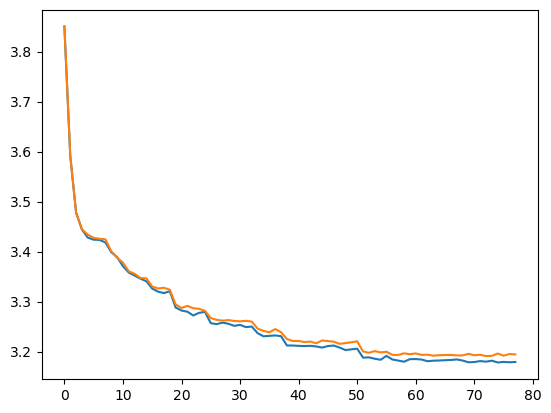

Training Done
['q', 'H', '2', 'q', 'R', 'W', '6', 'P', 'r', 'r', 'Q', 'r', 'B', 'H', 'O', 'Y', 'D', 'W', '7', 'Q', 'R', 'q', 'C', '0', 'J', 'X', 'q', 'N', 'X', 'M', '5', '5', '0', 'R', 'H', 'F', 'Y', 'X', 'H', 'M', '5', 'A', 'J', 'Y', 't', 'U', 'V', '6', 'U', 'N', 'Q', 'V', 'b', 'A', 'C', 'Y', 'F', 'F', 'U', 'B', 'A', 'O', 'W', 'O', 'O', 'K', '1', '1', 'Y', 'H', 'F', 'q', '7', 'q', 'X', 'I', 'Q', 'r', 'W', '6', 'F', 'D', '5', '1', 'O', 'Z', 'Z', 'F', 't', 'X', 'H', 'F', 'A', 'Y', 'M', 'J', 'J', 'h', 'R', 'h']
['q', 'H', 'a', 'q', 'R', 'W', 'G', 'P', 'r', 'r', 'Q', 'r', '3', 'H', 'O', 'Y', 'D', 'W', '7', 'Q', 'C', 'q', 'C', '0', 'J', 'X', '9', 'N', 'X', 'M', 'G', '5', '0', 'R', 'H', 'F', '4', 'X', '4', 'M', '5', 'n', 'J', 'Y', 't', 'U', 'V', '6', 'U', 'N', 'Q', 'V', 'b', 'A', 'C', 'Y', 'E', 'E', '4', '3', 'A', 'a', 'W', 'O', 'O', 'K', 'L', 'L', 'X', '4', 'F', 'q', '7', 'a', 'X', '1', 'a', 'r', 'W', '6', 'F', '0', 'G', '1', 'D', 'Z', 'Z', 'f', 't', 'X', 'H', 'F', 'B', 'Y', 'M', 'J', 'J',

C:\Users\Destiny\AppData\Local\Temp\ipykernel_51480\1654886696.py:37: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = F.softmax(self.fc4(out),dim=None)


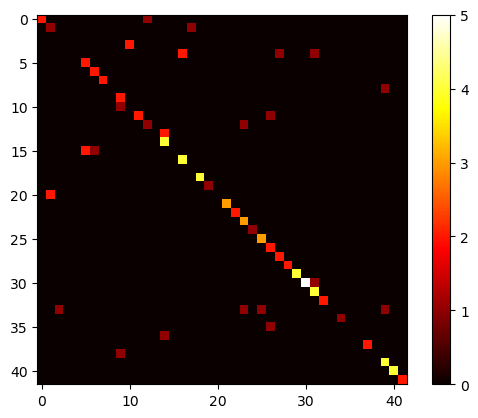

In [36]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.show()
print('Training Done')
m.predict(frame_test, 100)

0.0001

### Checking State Dicts of Model and Optim

In [ ]:
print('Model State Dict')
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

In [ ]:
print('Optimizer State Dict')
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

### Saving Model Checkpoint

In [37]:
torch.save(model.state_dict(), 'OCR Neural Network/OCRModel_3.1793_3.1944.pth') #Training Loss: 3.1793, Validation Loss: 3.1944

In [38]:
torch.save(optimizer.state_dict(), 'OCR Neural Network/Optimizer_3.1793_3.1944.pth')

In [10]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model2.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model2(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    out['accuracy'] = get_accuracy()
    model2.train()
    return out

@torch.no_grad()
def get_accuracy():
    model2.eval()
    correct = 0
    total = 0
    for i in range(1000):
        X, Y = get_batch('val')
        logits, _ = model2(X, Y)
        _, predicted = torch.max(logits, 1)
        total += Y.size(0)
        correct += (predicted == Y).sum().item()
    model2.train()
    return correct / total

C:\Users\Destiny\AppData\Local\Temp\ipykernel_5064\1654886696.py:37: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = F.softmax(self.fc4(out),dim=None)


['A', 'W', '5', 'D', 'q', 'T', 'H', 'I', 'R', '5', 'T', 'Q', 'B', 'H', 'Q', 'q', 'C', 'W', 'h', 'A', 'Y', '5', '1', 'Z', 'C', 'Z', 'q', 'C', '6', '1', '1', 'I', 'T', 'Y', 'M', 'I', '5', 'F', 'b', 'M', 'U', 'P', '5', 'Z', '6', 'U', 'd', 'q', 'J', 'I', 'I', '6', 'F', 'U', 'O', 'I', 'b', 'R', 'b', '6', 'V', 'R', 'Z', 't', 'C', 'R', 'W', '5', 'Q', 'N', 'M', 'W', '0', 'Z', '0', 'M', 'A', 'D', '6', 'R', 'Z', 'B', '6', 'M', '2', 'I', '5', 'I', 'R', '2', 'V', 'Z', 'F', 't', 'd', 'q', 'L', '6', 'H', 'q', 'h', 'X', 'q', 'b', 'q', '6', 'A', 'B', 'F', 'h', 'R', '2', 'X', 'q', 'q', 'r', '0', '3', 'K', '2', 'A', 'Y', 'M', 'q', 'h', 'R', '5', '7', '5', 'h', 'Z', 'R', '5', 'R', 'X', 'Z', 'W', 'b', 'Z', 'Z', 'Z', 'P', 'Q', 'b', 'L', '6', 'V', 'M', 'Z', 'C', 'Y', 'R', 'N', '0', 'A', '0', 'I', '7', 'q', 'A', 'd', '2', 'r', 'V', 'V', 'C', '2', 'q', 'q', 'Y', 'F', '1', 'Z', '8', 'V', 'J', '5', 'C', '5', 't', 'C', '5', 'q', 'M', '8', '6', 'Z', 'N', 'A', '6', '5', 'q', 'L', '6', '6', 'R', 'U', 'O', 'L', 't',

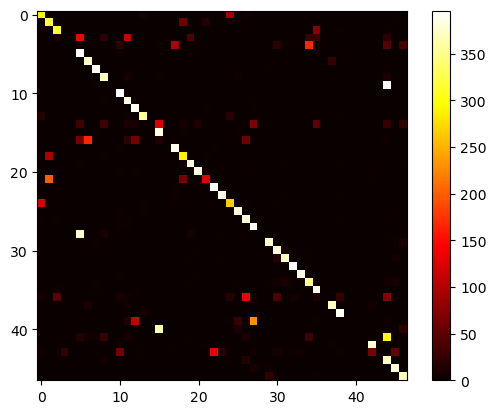

C:\Users\Destiny\AppData\Local\Temp\ipykernel_5064\1654886696.py:37: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = F.softmax(self.fc4(out),dim=None)


0.6964375

In [11]:
model2 = OCRCNN()
model2.load_state_dict(torch.load(r'C:\Jupyters\OCR Neural Network\OCR_3.1793_3.1944 GELU+32_64Conv Layer\OCRModel_3.1793_3.1944.pth'))
model2.eval()
model2 = model2.to(device)
model2.predict(frame_test, frame_test.shape[0])
get_accuracy()